# TRABAJO FINAL


## Análisis de la distribución y comportamiento de los registros de sanciones durante el primer semestre de 2026
### OBJETIVO
Analizar la distribución y el comportamiento de los registros de sanciones durante el primer semestre de 2026, considerando el formulario, periodo, municipio y entidad que sanciona, mediante el procesamiento y análisis de los datos con Colab.

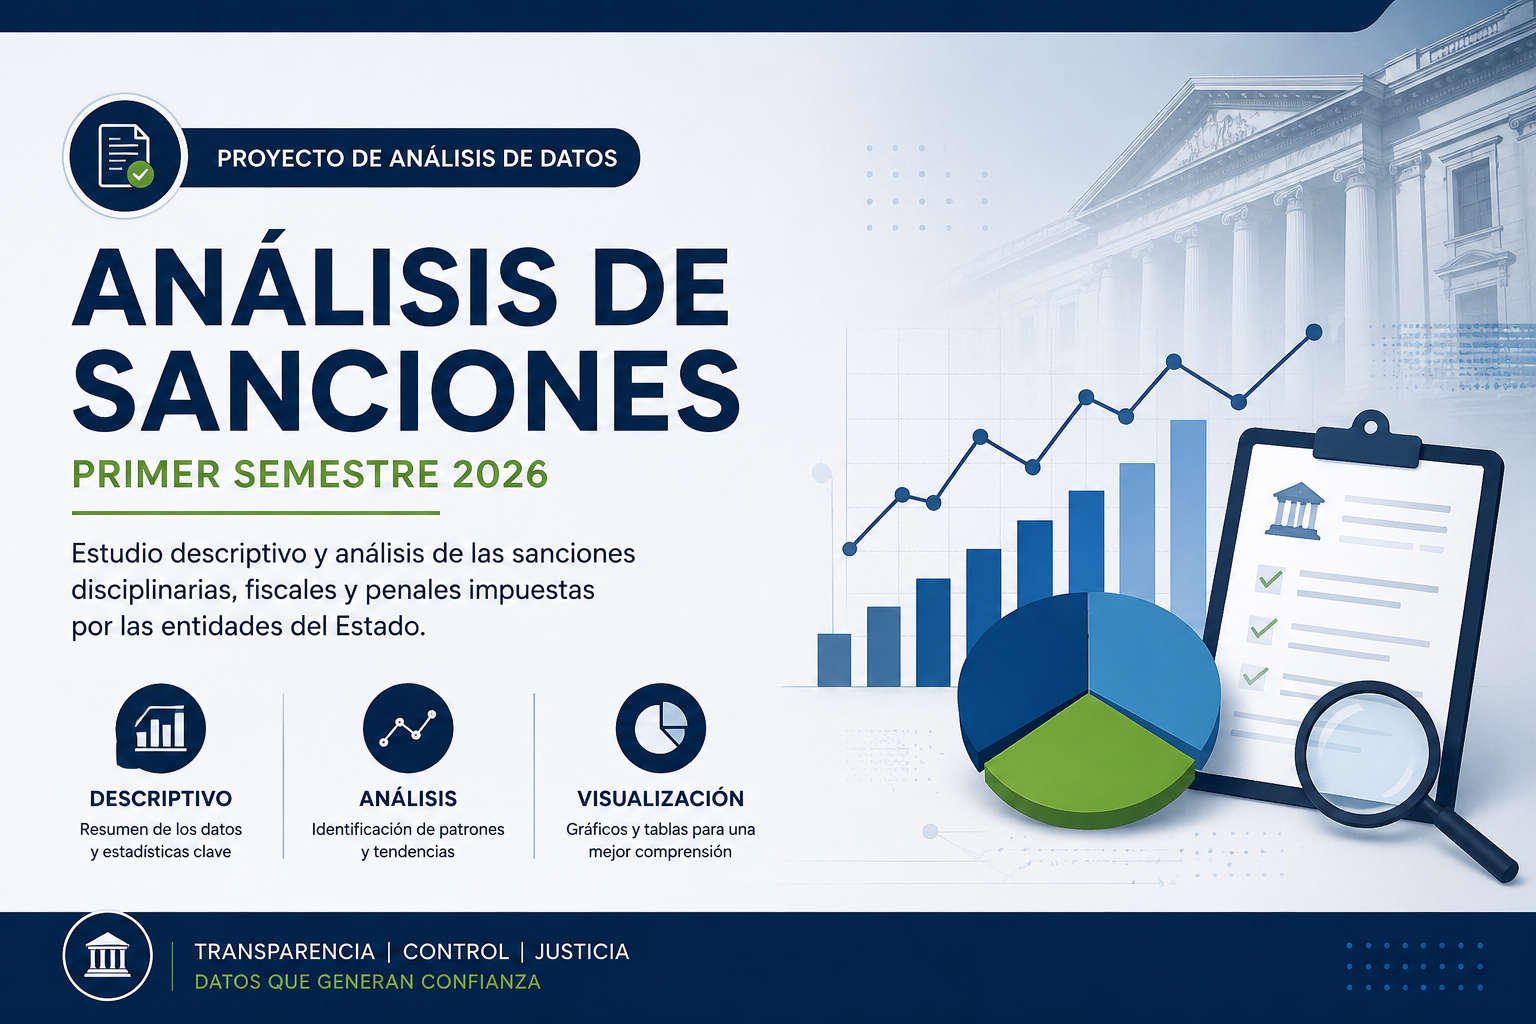
### Pregunta de análisis
#### ¿Cómo se distribuyen y comportan los registros de sanciones durante el primer semestre de 2026, según formulario, periodo, municipio y entidad que sanciona?
#### Unidad de análisis: Cada registro del conjunto de datos representa una observación consolidada de sanciones asociada a una combinación de variables como el año, mes, formulario, municipio y entidad. La variable Cantidad_Sanciones representa el número de sanciones registradas para cada combinación.

## IMPORTAR LIBRERIAS
En esta sección se importan las bibliotecas necesarias para realizar la manipulación, exploración y visualización de los datos. Pandas permite trabajar con estructuras tabulares, NumPy facilita operaciones numéricas y Matplotlib y Seaborn permiten generar representaciones gráficas de los resultados.




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## CARGAR REPORTE
El conjunto de datos se encuentra almacenado en un archivo de Excel que contiene información consolidada sobre registros de sanciones durante el primer semestre de 2026. El archivo integra información proveniente de los formularios Disciplinario, Penal y Fiscal.

Primero indicamos el archivo que vamos a utilizar, lo cargamos con Pandas y mostramos las primeras filas para verificar que se haya cargado correctamente.”

In [ ]:
ruta = "REPORTE__2026.xlsx"

data = pd.read_excel(ruta)

print("Archivo cargado correctamente.")
print(data.head())

Archivo cargado correctamente.
   Anio  Mes     Formulario Municipio                              Entidad  \
0  2026    1  DISCIPLINARIO       NaN            BANCO AGRARIO DE COLOMBIA   
1  2026    1  DISCIPLINARIO       NaN                    EJERCITO NACIONAL   
2  2026    1  DISCIPLINARIO       NaN        FUERZA AEREA COLOMBIANA -FAC-   
3  2026    1  DISCIPLINARIO       NaN                 GOBERNACION DE SUCRE   
4  2026    1  DISCIPLINARIO   ACACIAS  ALCALDIA MUNICIPIO - ACACIAS (META)   

   Cantidad_Sanciones  
0                   1  
1                   2  
2                   2  
3                   1  
4                   3  


## Exploración inicial de los datos
Antes de realizar los análisis y cálculos, es necesario conocer la estructura general del conjunto de datos. En esta sección se revisa el número de filas y columnas, los tipos de datos almacenados y la información general disponible.

Aquí verificamos el tamaño de la base y encontramos 1.340 registros distribuidos en 6 variables.

data.shape nos permite conocer el tamaño de la base de datos, indicando cuántos registros y cuántas variables tenemos.

In [ ]:
print("Número de filas y columnas:")

data.shape

Número de filas y columnas:


(1340, 6)

In [ ]:
data.dtypes
#nos permite verificar qué tipo de dato tiene cada columna, para asegurarnos de que la información esté correctamente estructurada.

,0
Anio,int64
Mes,int64
Formulario,object
Municipio,object
Entidad,object
Cantidad_Sanciones,int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Anio                1340 non-null   int64 
 1   Mes                 1340 non-null   int64 
 2   Formulario          1340 non-null   object
 3   Municipio           1315 non-null   object
 4   Entidad             1340 non-null   object
 5   Cantidad_Sanciones  1340 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 62.9+ KB


In [ ]:
data.describe()

,Anio,Mes,Cantidad_Sanciones
count,1340.0,1340.000000,1340.000000
mean,2026.0,3.477612,2.039552
std,0.0,1.717617,3.410534
min,2026.0,1.000000,1.000000
25%,2026.0,2.000000,1.000000
50%,2026.0,3.000000,1.000000
75%,2026.0,5.000000,2.000000
max,2026.0,6.000000,50.000000


## Evaluación de la calidad de los datos
La calidad de los datos es un aspecto fundamental para garantizar que los resultados obtenidos sean interpretados adecuadamente. Por esta razón, se realiza una revisión de los valores faltantes y de la posible existencia de registros duplicados.

Aquí identificamos los registros que tienen al menos un dato faltante para revisar la calidad de la información.

In [ ]:
print("Registros con información faltante:")

data[data.isnull().any(axis=1)].head(-1)

Registros con información faltante:


,Anio,Mes,Formulario,Municipio,Entidad,Cantidad_Sanciones
0,2026,1,DISCIPLINARIO,NaN,BANCO AGRARIO DE COLOMBIA,1
1,2026,1,DISCIPLINARIO,NaN,EJERCITO NACIONAL,2
2,2026,1,DISCIPLINARIO,NaN,FUERZA AEREA COLOMBIANA -FAC-,2
3,2026,1,DISCIPLINARIO,NaN,GOBERNACION DE SUCRE,1
441,2026,2,PENAL,NaN,FUERZAS PUBLICAS,6
457,2026,3,DISCIPLINARIO,NaN,CENTRO DE FORMACION INTEGRAL PARA EL TRABAJO C...,1
458,2026,3,DISCIPLINARIO,NaN,EJERCITO NACIONAL,4
459,2026,3,DISCIPLINARIO,NaN,INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO ...,1
693,2026,3,PENAL,NaN,FUERZAS PUBLICAS,3
700,2026,4,DISCIPLINARIO,NaN,COMANDO GENERAL DE LAS FUERZAS MILITARES - EJE...,1


In [ ]:
data[data["Municipio"].isnull()][
    [
        "Anio",
        "Mes",
        "Formulario",
        "Municipio",
        "Entidad",
        "Cantidad_Sanciones"
    ]
].head(-1)

,Anio,Mes,Formulario,Municipio,Entidad,Cantidad_Sanciones
0,2026,1,DISCIPLINARIO,NaN,BANCO AGRARIO DE COLOMBIA,1
1,2026,1,DISCIPLINARIO,NaN,EJERCITO NACIONAL,2
2,2026,1,DISCIPLINARIO,NaN,FUERZA AEREA COLOMBIANA -FAC-,2
3,2026,1,DISCIPLINARIO,NaN,GOBERNACION DE SUCRE,1
441,2026,2,PENAL,NaN,FUERZAS PUBLICAS,6
457,2026,3,DISCIPLINARIO,NaN,CENTRO DE FORMACION INTEGRAL PARA EL TRABAJO C...,1
458,2026,3,DISCIPLINARIO,NaN,EJERCITO NACIONAL,4
459,2026,3,DISCIPLINARIO,NaN,INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO ...,1
693,2026,3,PENAL,NaN,FUERZAS PUBLICAS,3
700,2026,4,DISCIPLINARIO,NaN,COMANDO GENERAL DE LAS FUERZAS MILITARES - EJE...,1


Se identificaron registros sin información de municipio. Estos registros se conservaron en el conjunto de datos, debido a que contienen información válida sobre el formulario, la entidad y la cantidad de sanciones. Para los análisis territoriales, la ausencia de municipio se interpreta como información territorial no disponible.


# Identificación de registros duplicados
Los registros duplicados pueden afectar los resultados si representan información repetida sin justificación. Por esta razón, se verifica su existencia dentro del conjunto de datos.

En nuestro Caso el resultado es 0

In [ ]:
data.duplicated().sum()

np.int64(0)

## Transformación de variables
Para facilitar la interpretación de los resultados temporales, se transforma la variable numérica Mes en una variable que contiene el nombre correspondiente de cada mes.

Convertimos los números de los meses en sus respectivos nombres, creamos una nueva columna y verificamos el resultado mostrando las primeras filas.”

In [ ]:
meses = {
1:"Enero",
2:"Febrero",
3:"Marzo",
4:"Abril",
5:"Mayo",
6:"Junio",
7:"Julio",
8:"Agosto",
9:"Septiembre",
10:"Octubre",
11:"Noviembre",
12:"Diciembre"
}

data["Nombre_Mes"] = data["Mes"].map(meses)

data.head()

,Anio,Mes,Formulario,Municipio,Entidad,Cantidad_Sanciones,Nombre_Mes
0,2026,1,DISCIPLINARIO,NaN,BANCO AGRARIO DE COLOMBIA,1,Enero
1,2026,1,DISCIPLINARIO,NaN,EJERCITO NACIONAL,2,Enero
2,2026,1,DISCIPLINARIO,NaN,FUERZA AEREA COLOMBIANA -FAC-,2,Enero
3,2026,1,DISCIPLINARIO,NaN,GOBERNACION DE SUCRE,1,Enero
4,2026,1,DISCIPLINARIO,ACACIAS,ALCALDIA MUNICIPIO - ACACIAS (META),3,Enero


## Indicadores generales de las sanciones
En esta sección se calculan indicadores generales que permiten obtener una visión global del conjunto de datos. Se calcula el total de sanciones registradas, así como el promedio y la mediana de la variable Cantidad_Sanciones.

Es importante diferenciar entre el número de filas del archivo y el total de sanciones: cada fila representa un registro consolidado, mientras que el total de sanciones se obtiene mediante la suma de la variable Cantidad_Sanciones.


En este bloque calculamos el total, el promedio y la mediana de las sanciones. Obtuvimos 2.733 sanciones, un promedio de 2,04 y una mediana de




In [ ]:
total = data["Cantidad_Sanciones"].sum()

print("Total sanciones:", total)

print("Promedio:", data["Cantidad_Sanciones"].mean())

print("Mediana:", data["Cantidad_Sanciones"].median())

Total sanciones: 2733
Promedio: 2.03955223880597
Mediana: 1.0


## Análisis temporal de las sanciones
Para analizar el comportamiento de las sanciones durante el periodo estudiado, se agrupan los datos según el año y el mes. Se calcula tanto el número de registros consolidados como el total de sanciones para cada periodo.

Este análisis permite identificar posibles variaciones en la cantidad de sanciones a lo largo del primer semestre de 2026.

Aquí agrupamos la información por año y mes para analizar el comportamiento de las sanciones en cada periodo.” Después calculamos dos valores: la cantidad de registros y el total de sanciones de cada mes.”

size → cuenta cuántos registros hay.
sum → suma la cantidad de sanciones.

In [ ]:
sanciones_mes = (
    data
    .groupby(["Anio","Mes"],as_index=False)
    .agg(
        registros=("Cantidad_Sanciones","size"),
        sanciones=("Cantidad_Sanciones","sum")
    )
)

sanciones_mes

,Anio,Mes,registros,sanciones
0,2026,1,214,416
1,2026,2,243,523
2,2026,3,243,527
3,2026,4,221,483
4,2026,5,167,302
5,2026,6,252,482


Aquí creamos una gráfica de líneas para visualizar cómo se comportaron las sanciones durante cada mes del semestre, facilitando la identificación de aumentos y disminuciones.

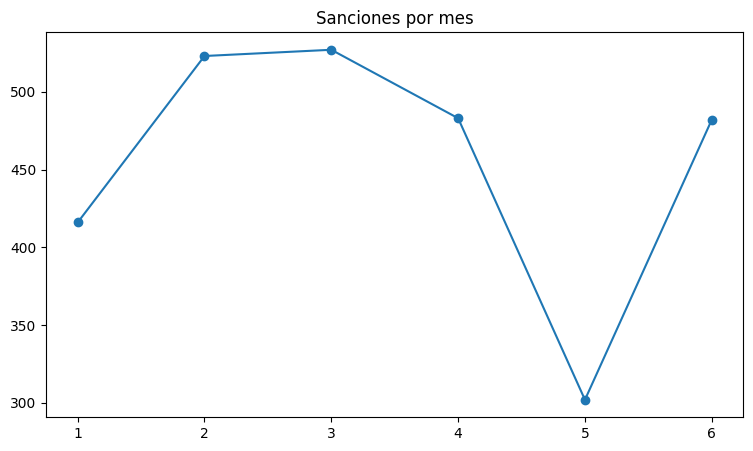

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    sanciones_mes["Mes"],
    sanciones_mes["sanciones"],
    marker="o"
)

plt.title("Sanciones por mes")

plt.show()

## Distribución de sanciones por formulario
El conjunto de datos integra información de los formularios Disciplinario, Penal y Fiscal. En esta sección se calcula la cantidad total de sanciones asociada a cada formulario, permitiendo comparar su participación dentro del conjunto de datos.

Agrupamos las sanciones por formulario y las sumamos para conocer cuánto aporta cada uno al total.”

In [ ]:
sanciones_formulario = (
    data
    .groupby("Formulario")
    ["Cantidad_Sanciones"]
    .sum()
    .reset_index()
)

sanciones_formulario

,Formulario,Cantidad_Sanciones
0,DISCIPLINARIO,2301
1,FISCAL,292
2,PENAL,140


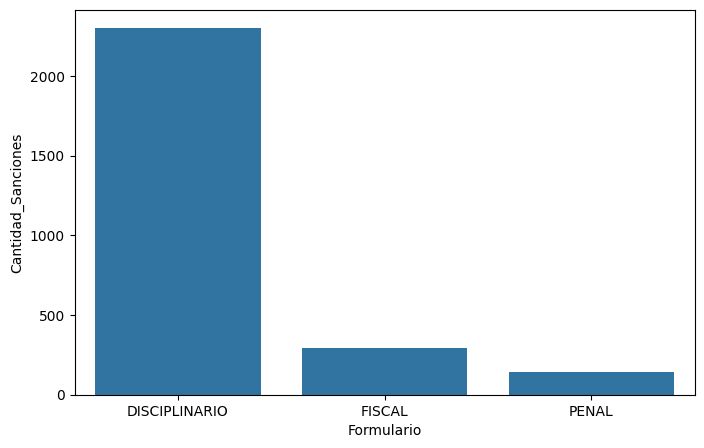

In [ ]:
# creamos un gráfico de barras para comparar visualmente la cantidad de sanciones entre los diferentes formularios.

plt.figure(figsize=(8,5))

sns.barplot(
    data=sanciones_formulario,
    x="Formulario",
    y="Cantidad_Sanciones"
)

plt.show()

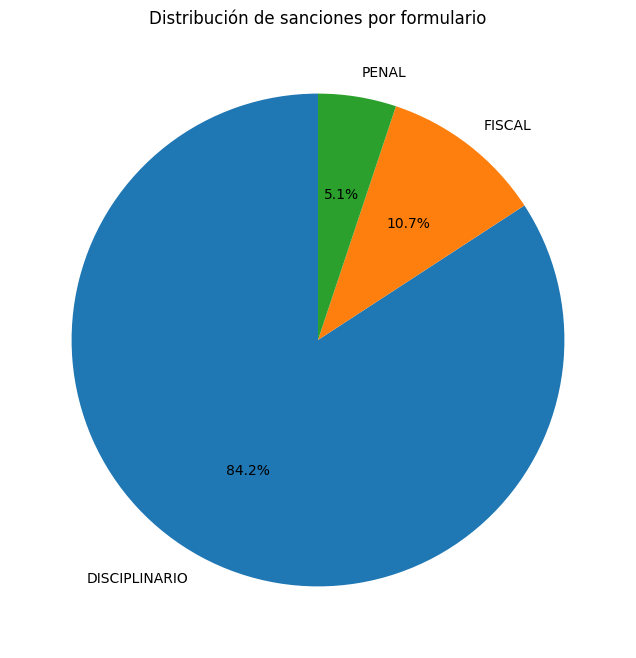

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    sanciones_formulario["Cantidad_Sanciones"],
    labels=sanciones_formulario["Formulario"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de sanciones por formulario")

plt.show()

## Comportamiento mensual según formulario
Para complementar el análisis temporal, se construye una tabla que permite comparar la cantidad de sanciones de cada formulario durante los diferentes meses del periodo analizado.

Creamos una tabla dinámica que nos permite comparar, mes a mes, la cantidad de sanciones de cada formulario.

In [ ]:
tabla = pd.pivot_table(
    data,
    index="Mes",
    columns="Formulario",
    values="Cantidad_Sanciones",
    aggfunc="sum",
    fill_value=0
)

tabla

Formulario,DISCIPLINARIO,FISCAL,PENAL
Mes,,,
1,344,42,30
2,451,41,31
3,449,58,20
4,399,59,25
5,244,37,21
6,414,55,13


## Análisis territorial e institucional
Además del comportamiento temporal y por formulario, se analizan las entidades y municipios que presentan las mayores cantidades acumuladas de sanciones durante el periodo estudiado.

Agrupamos las sanciones por entidad, las sumamos, las ordenamos de mayor a menor y seleccionamos las 15 entidades con más sanciones.

In [ ]:
top_entidades = (
    data
    .groupby("Entidad")
    ["Cantidad_Sanciones"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_entidades

,Cantidad_Sanciones
Entidad,
POLICIA NACIONAL,1389
EJERCITO NACIONAL,200
FUERZAS PUBLICAS,139
DIRECCION DE IMPUESTOS Y ADUANAS NACIONALES -DIAN,66
INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO -INPEC-,46
SECRETARIA DE EDUCACION DE BOGOTA,22
INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO - INPEC,21
BANCO AGRARIO DE COLOMBIA,20
ALCALDIA MUNICIPIO - ARMENIA (QUINDIO),17


In [ ]:
top_municipios = (
    data
    .groupby("Municipio")
    ["Cantidad_Sanciones"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_municipios


,Cantidad_Sanciones
Municipio,
BOGOTA DC,494
MEDELLIN,145
SANTIAGO DE CALI,122
BARRANQUILLA,108
CARTAGENA DE INDIAS,85
BUCARAMANGA,67
SAN JOSE DE CUCUTA,56
SANTA MARTA,49
SAN JUAN DE PASTO,47


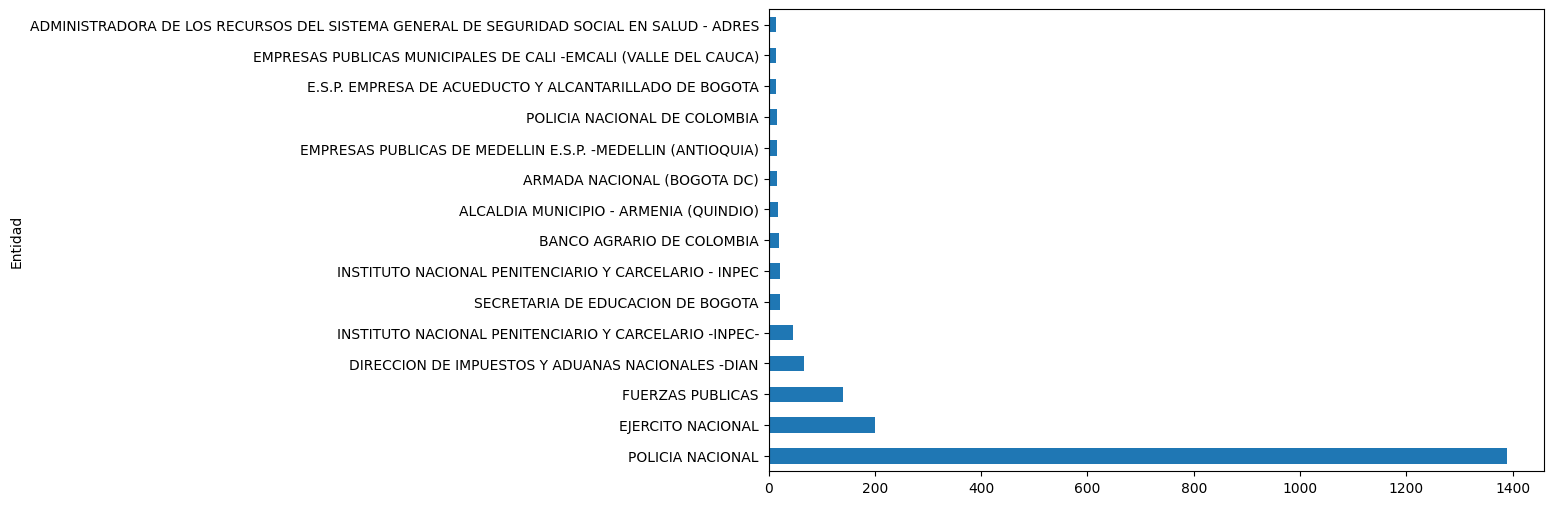

In [ ]:
top_entidades.plot(kind="barh", figsize=(10,6))

plt.show()

## Hallazgos principales
### Hallazgo 1. Comportamiento temporal

Los resultados muestran una clara concentración de las sanciones registradas en el formulario Disciplinario, con un total de 2.301 sanciones durante el primer semestre de 2026. En comparación, el formulario Fiscal registró 292 sanciones, mientras que el formulario Penal presentó 140 sanciones.

En conjunto, se analizaron 2.733 sanciones. Esto indica que el comportamiento general del conjunto de datos está influenciado principalmente por los registros del formulario Disciplinario, que concentra aproximadamente el 84,2 % del total de sanciones. Por su parte, el formulario Fiscal representa cerca del 10,7 % y el Penal aproximadamente el 5,1 %.

Por lo tanto, al interpretar los resultados generales del periodo, es importante tener en cuenta que las tendencias observadas estarán principalmente relacionadas con el comportamiento de los registros disciplinarios.

### Hallazgo 2. Distribución según formulario

Durante el primer semestre de 2026 se observa que la cantidad de sanciones presentó variaciones mensuales. El mayor número de sanciones se registró en marzo, con 527 sanciones, seguido de febrero, con 523 sanciones. Por otro lado, el menor valor se presentó en mayo, con 302 sanciones.

Los resultados muestran un comportamiento relativamente alto durante los primeros cuatro meses del semestre, seguido de una disminución importante en mayo y una recuperación en junio, cuando se registraron 482 sanciones.

Este comportamiento evidencia que la distribución de las sanciones no fue uniforme durante el periodo analizado. Sin embargo, con las variables disponibles no es posible determinar las causas de las variaciones mensuales.

### Hallazgo 3. Concentración territorial e institucional

Al analizar los formularios por mes, se observa que el formulario Disciplinario mantiene la mayor cantidad de sanciones durante todos los meses del primer semestre. Su valor más alto se presenta en febrero con 451 sanciones, seguido de marzo con 449 sanciones.

El formulario Fiscal presenta una distribución más estable, con valores que oscilan entre 37 y 59 sanciones. Su mayor cantidad se registra en abril, con 59 sanciones.

Por su parte, el formulario Penal presenta las cantidades más bajas de los tres formularios durante todo el periodo. Su mayor valor se observa en febrero con 31 sanciones, mientras que su menor valor se presenta en junio con 13 sanciones.

En general, la tabla mensual confirma que el formulario Disciplinario tiene una participación predominante durante todo el semestre y que las variaciones del total mensual están estrechamente relacionadas con los cambios en este formulario.

## Hallazgo 4. Concentración institucional de las sanciones
El análisis por entidad muestra una concentración importante de sanciones en algunas instituciones. La Policía Nacional presenta el mayor número de sanciones acumuladas, con 1.389, una cifra considerablemente superior a la de las demás entidades registradas.

En segundo lugar se encuentra el Ejército Nacional, con 200 sanciones, seguido de Fuerzas Públicas, con 139 sanciones. Después de estas entidades se observa una reducción significativa en las cantidades registradas, siendo la DIAN la siguiente entidad con 66 sanciones.

Estos resultados permiten identificar que una parte importante de las sanciones analizadas se concentra en un número reducido de entidades. Sin embargo, esta concentración no permite afirmar por sí sola que dichas entidades presenten un mayor nivel de incumplimiento, ya que el conjunto de datos no incluye variables relacionadas con el tamaño de cada entidad, el número de funcionarios u otros factores que permitan realizar una comparación proporcional.

## Hallazgo 5. Distribución territorial de las sanciones

En el análisis por municipio, Bogotá D.C. presenta la mayor cantidad acumulada de sanciones, con 494 registros, seguida por Medellín, con 145, y Santiago de Cali, con 122.

También se destacan Barranquilla, con 108 sanciones, y Cartagena de Indias, con 85. Los demás municipios del listado presentan cantidades inferiores, aunque continúan mostrando la presencia de registros de sanciones en diferentes territorios del país.


## CONCLUSIONES
El análisis realizado permitió responder a la pregunta planteada sobre la distribución y comportamiento de los registros de sanciones durante el primer semestre de 2026, considerando las variables de formulario, periodo, municipio y entidad.

En primer lugar, se identificó que el formulario Disciplinario concentra la mayor proporción de sanciones del conjunto de datos, representando aproximadamente el 84 % del total. Esto demuestra que este formulario tiene un peso predominante dentro de la información analizada y, por tanto, influye de manera importante en el comportamiento general de las sanciones durante el periodo.

Desde una perspectiva temporal, las mayores cantidades de sanciones se registraron durante febrero y marzo, mientras que mayo presentó la menor cantidad. Posteriormente, en junio se evidenció un aumento frente al mes anterior. Esto demuestra que la distribución mensual de las sanciones presentó variaciones y no se mantuvo constante durante el semestre.

El análisis institucional permitió identificar una concentración importante en determinadas entidades, especialmente en la Policía Nacional, mientras que territorialmente Bogotá D.C. presentó la mayor cantidad acumulada de sanciones entre los municipios analizados.

En general, el uso de las librerias Python permitió procesar y organizar el conjunto completo de información de manera automatizada, facilitando la obtención de indicadores y visualizaciones para comprender la distribución de los registros desde diferentes perspectivas.

## Limitaciones del análisis
El presente análisis se limita a la información disponible en el conjunto de datos correspondiente al primer semestre de 2026. Los resultados permiten describir la distribución y el comportamiento de los registros de sanciones, pero no permiten establecer las causas que explican las diferencias observadas entre formularios, meses, entidades o municipios.

Asimismo, las comparaciones realizadas se basan en cantidades absolutas de sanciones. Por esta razón, no es posible determinar si una entidad o municipio presenta proporcionalmente una mayor incidencia sin contar con información adicional que permita contextualizar los resultados.
